In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import math

# ============== RECUIT SIMULÉ POUR L'OPTIMISATION ==============

def simulated_annealing_feature_selection(X_train, y_train, X_val, y_val, n_iterations=30, initial_temp=100):
    """Sélection de features avec Recuit Simulé"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Sélection de Features")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        """Évalue un sous-ensemble de features"""
        if len(selected_indices) == 0:
            return 0
        
        X_train_sub = X_train[:, selected_indices]
        X_val_sub = X_val[:, selected_indices]
        
        # Évaluation rapide avec un arbre simple
        dt = DecisionTree(max_depth=5, min_samples_split=5)
        dt.fit(X_train_sub, y_train, progress_tracker=None)
        score = np.mean(dt.predict(X_val_sub) == y_val)
        
        # Pénalité pour trop peu/beaucoup de features
        n_selected = len(selected_indices)
        if n_selected < 5:
            score -= (5 - n_selected) * 0.05
        elif n_selected > 20:
            score -= (n_selected - 20) * 0.02
            
        return max(0, score)
    
    # Solution initiale : sélection aléatoire
    current_solution = np.random.choice(n_features, size=np.random.randint(10, 16), replace=False)
    current_score = evaluate_features(current_solution)
    
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"🎯 Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        # Générer un voisin
        neighbor_solution = current_solution.copy()
        
        # Opération aléatoire
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                new_feature = np.random.choice(available_features)
                neighbor_solution = np.append(neighbor_solution, new_feature)
                
        elif operation == 'remove' and len(neighbor_solution) > 5:
            remove_idx = np.random.randint(len(neighbor_solution))
            neighbor_solution = np.delete(neighbor_solution, remove_idx)
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                remove_idx = np.random.randint(len(neighbor_solution))
                new_feature = np.random.choice(available_features)
                neighbor_solution[remove_idx] = new_feature
        
        # Évaluer le voisin
        neighbor_score = evaluate_features(neighbor_solution)
        
        # Accepter ou rejeter
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        # Mettre à jour la meilleure solution
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        # Refroidissement
        temperature = initial_temp * (0.95 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURES FEATURES SÉLECTIONNÉES:")
    print(f"   Nombre de features: {len(best_solution)}")
    print(f"   Features indices: {best_solution}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_solution

def simulated_annealing_hyperparams(X_train, y_train, X_val, y_val, n_iterations=20, initial_temp=50):
    """Optimisation des hyperparamètres avec Recuit Simulé"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Optimisation des Hyperparamètres")
    print("="*60)
    
    param_space = {
        'max_depth': [5, 10, 15, 20, 25],
        'min_samples_split': [2, 5, 10, 15]
    }
    
    def evaluate_params(params):
        """Évalue un ensemble de paramètres"""
        dt = DecisionTree(**params)
        dt.fit(X_train, y_train, progress_tracker=None)
        return np.mean(dt.predict(X_val) == y_val)
    
    # Solution initiale aléatoire
    current_params = {
        'max_depth': np.random.choice(param_space['max_depth']),
        'min_samples_split': np.random.choice(param_space['min_samples_split'])
    }
    current_score = evaluate_params(current_params)
    
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"🎯 Paramètres initiaux: {current_params}, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        # Générer des paramètres voisins
        neighbor_params = current_params.copy()
        
        # Modifier un paramètre aléatoire
        param_to_change = np.random.choice(list(param_space.keys()))
        neighbor_params[param_to_change] = np.random.choice(param_space[param_to_change])
        
        # Évaluer les nouveaux paramètres
        neighbor_score = evaluate_params(neighbor_params)
        
        # Accepter ou rejeter
        if neighbor_score > current_score:
            current_params = neighbor_params
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_params = neighbor_params
                current_score = neighbor_score
        
        # Mettre à jour la meilleure solution
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {best_params}, score: {best_score:.3f}")
        
        # Refroidissement
        temperature = initial_temp * (0.9 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURS PARAMÈTRES:")
    print(f"   max_depth: {best_params['max_depth']}")
    print(f"   min_samples_split: {best_params['min_samples_split']}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_params, best_score

# ============== CLASSES ORIGINALES (LÉGÈREMENT OPTIMISÉES) ==============

class ProgressTracker:
    def __init__(self, total_steps, model_name="Decision Tree"):
        self.total_steps = total_steps
        self.current_step = 0
        self.model_name = model_name
        
    def update(self, step_description=None):
        self.current_step += 1
        progress = (self.current_step / self.total_steps) * 100
        if step_description:
            print(f"🔵 [{self.model_name}] Étape {self.current_step}/{self.total_steps} ({progress:.1f}%) - {step_description}")
        else:
            print(f"🔵 [{self.model_name}] Étape {self.current_step}/{self.total_steps} ({progress:.1f}%)")
    
    def start(self):
        print(f"\n🚀 Début de l'entraînement du modèle {self.model_name}")
        print(f"📋 Total des étapes: {self.total_steps}")
    
    def complete(self):
        print(f"✅ [{self.model_name}] Entraînement terminé!")

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_nodes = 0
        
    def entropy(self, y):
        """Entropy optimisée"""
        if len(y) == 0:
            return 0
        p = np.bincount(y) / len(y)
        return -np.sum(p * np.log2(p + 1e-10))
    
    def information_gain(self, X_column, y, threshold):
        """Gain d'information optimisé"""
        parent_entropy = self.entropy(y)
        
        left_mask = X_column <= threshold
        right_mask = ~left_mask
        
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0
        
        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        entropy_left = self.entropy(y[left_mask])
        entropy_right = self.entropy(y[right_mask])
        
        child_entropy = (n_left / n) * entropy_left + (n_right / n) * entropy_right
        return parent_entropy - child_entropy
    
    def best_split(self, X, y):
        """Recherche de split optimisée"""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            # Échantillonnage des thresholds pour accélérer
            if len(X_column) > 20:
                thresholds = np.percentile(X_column, [25, 50, 75])
            else:
                thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self.information_gain(X_column, y, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Conditions d'arrêt
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            n_classes == 1):
            leaf_value = np.bincount(y.astype(int)).argmax()
            self.n_nodes += 1
            return Node(value=leaf_value)
        
        # Trouver le meilleur split
        best_feature, best_threshold, best_gain = self.best_split(X, y)
        
        if best_gain == 0:
            leaf_value = np.bincount(y.astype(int)).argmax()
            self.n_nodes += 1
            return Node(value=leaf_value)
        
        # Créer les sous-arbres
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold
        
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        self.n_nodes += 1
        return Node(best_feature, best_threshold, left_subtree, right_subtree)
    
    def fit(self, X, y, progress_tracker=None):
        if progress_tracker:
            progress_tracker.start()
            progress_tracker.update("Construction de l'arbre...")
        
        self.root = self.build_tree(X, y)
        
        if progress_tracker:
            progress_tracker.update(f"Arbre construit avec {self.n_nodes} noeuds")
            progress_tracker.complete()
    
    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        predictions = []
        total = len(X)
        
        for i, x in enumerate(X):
            pred = self.predict_sample(x, self.root)
            predictions.append(pred)
            
            if (i + 1) % max(1, total // 10) == 0 or i == total - 1:
                progress = (i + 1) / total * 100
                print(f"🔵 [Decision Tree] Prédiction: {i+1}/{total} échantillons ({progress:.1f}%)")
        
        return np.array(predictions)

# ============== FONCTIONS DE MÉTRIQUES ==============

def confusion_matrix_multiclass(Ytt, y_pred):
    classes = sorted(set(Ytt)) 
    n = len(classes)  
    
    matrix = [[0 for _ in range(n)] for _ in range(n)]
    
    for i in range(len(Ytt)):
        if y_pred[i] not in classes:
            continue 
        
        true_class = classes.index(Ytt[i])
        pred_class = classes.index(y_pred[i])
        matrix[true_class][pred_class] += 1

    TP_classes, FP_classes, TN_classes, FN_classes = [], [], [], []
    conf_matrix = np.array(matrix)
    
    for i in range(n):
        TP = conf_matrix[i, i]
        FP = sum(conf_matrix[:, i]) - TP
        FN = sum(conf_matrix[i, :]) - TP
        TN = conf_matrix.sum() - (TP + FP + FN)

        TP_classes.append(TP)
        FP_classes.append(FP)
        TN_classes.append(TN)
        FN_classes.append(FN)

    return TP_classes, FP_classes, TN_classes, FN_classes

def accuracy(TP, TN, FP, FN):
    accuracies = []
    for i in range(len(TP)):
        acc = (TP[i] + TN[i]) / (TP[i] + TN[i] + FP[i] + FN[i]) if (TP[i] + TN[i] + FP[i] + FN[i]) != 0 else 0
        accuracies.append(acc)
    return accuracies

def recall(TP, FN):
    recalls = []
    for i in range(len(TP)):
        rec = TP[i] / (TP[i] + FN[i]) if (TP[i] + FN[i]) != 0 else 0
        recalls.append(rec)
    return recalls

def precision(TP, FP):
    precisions = []
    for i in range(len(TP)):
        prec = TP[i] / (TP[i] + FP[i]) if (TP[i] + FP[i]) != 0 else 0
        precisions.append(prec)
    return precisions

def taux_FP(FP, TN):
    fpr_values = []
    for i in range(len(FP)):
        fpr = FP[i] / (FP[i] + TN[i]) if (FP[i] + TN[i]) != 0 else 0
        fpr_values.append(fpr)
    return fpr_values

def specificity(TN, FP):
    specificity_values = []
    for i in range(len(TN)):
        spc = TN[i] / (TN[i] + FP[i]) if (TN[i] + FP[i]) != 0 else 0
        specificity_values.append(spc)
    return specificity_values

# ============== PROGRAMME PRINCIPAL ==============

print("="*60)
print("🔥 DECISION TREE - RECUIT SIMULÉ (DATASET COMPLET)")
print("="*60)

# Chargement des données
print("📁 Chargement des données...")
df = pd.read_csv("balanced_dataset_hybrid_FULL.csv")
print(f"✅ Données chargées: {df.shape}")

# UTILISATION DE TOUT LE DATASET (supprime le sous-échantillonnage)
print(f"📊 Dataset complet: {df.shape}")

# Vérification des données
print(f"Colonnes disponibles: {df.columns.tolist()}")
print(f"Valeurs uniques dans 'fire': {df['fire'].unique()}")
print(f"Distribution de 'fire':\n{df['fire'].value_counts()}")

# Séparation des features et target
columns_to_exclude = ['acq_date','X','Y','confidence']
feature_columns = [col for col in df.columns if col not in columns_to_exclude and col != 'fire']

print(f"\n🎯 Features utilisées ({len(feature_columns)}):")
print(feature_columns)

X = df[feature_columns].values
Y = df['fire'].values

print(f"\n📊 Dimensions:")
print(f"X shape: {X.shape}")
print(f"y shape: {Y.shape}")
print(f"Distribution des classes: {np.unique(Y, return_counts=True)}")

# Normalisation et split 80-20
print("\n🔧 Préprocessing des données...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80-20 avec validation
print("\n" + "="*60)
print("📊 SPLIT DES DONNÉES 80-20")
print("="*60)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=42, stratify=Y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"✅ Train: {X_train.shape} ({len(y_train)} échantillons)")
print(f"✅ Val:   {X_val.shape} ({len(y_val)} échantillons)") 
print(f"✅ Test:  {X_test.shape} ({len(y_test)} échantillons)")

# OPTIMISATION AVEC RECUIT SIMULÉ
print("\n" + "="*60)
print("🚀 OPTIMISATION AVEC RECUIT SIMULÉ")
print("="*60)

start_time = time.time()

# 1. Sélection de features
selected_indices = simulated_annealing_feature_selection(
    X_train, y_train, X_val, y_val, 
    n_iterations=25,
    initial_temp=80
)

# Appliquer la sélection
X_train_selected = X_train[:, selected_indices]
X_val_selected = X_val[:, selected_indices]
X_test_selected = X_test[:, selected_indices]

print(f"\n✅ Features après sélection: {X_train_selected.shape[1]}")

# 2. Optimisation des hyperparamètres
best_params, best_score = simulated_annealing_hyperparams(
    X_train_selected, y_train, X_val_selected, y_val,
    n_iterations=15,
    initial_temp=40
)

optimization_time = time.time() - start_time
print(f"⏱️ Temps d'optimisation: {optimization_time:.2f}s")

# ENTRAÎNEMENT FINAL AVEC CONFIGURATION OPTIMALE
print("\n" + "="*60)
print("🌳 ENTRAÎNEMENT FINAL DU DECISION TREE")
print("="*60)

progress_tracker = ProgressTracker(total_steps=2, model_name="Decision Tree Optimisé")

# Créer et entraîner l'arbre avec les meilleurs paramètres
dt_optimized = DecisionTree(**best_params)
dt_optimized.fit(X_train_selected, y_train, progress_tracker=progress_tracker)

# PRÉDICTIONS ET ÉVALUATION
print("\n" + "="*60)
print("📊 ÉVALUATION COMPLÈTE")
print("="*60)

# Prédictions sur tous les ensembles
print("\n🔮 Prédictions en cours...")
y_pred_train = dt_optimized.predict(X_train_selected)
y_pred_val = dt_optimized.predict(X_val_selected)
y_pred_test = dt_optimized.predict(X_test_selected)

# Calcul des accuracy
train_accuracy = np.mean(y_pred_train == y_train)
val_accuracy = np.mean(y_pred_val == y_val)
test_accuracy = np.mean(y_pred_test == y_test)

print(f"\n🎯 Résultats Decision Tree Optimisé:")
print(f"📈 Train Accuracy: {train_accuracy*100:.2f}%")
print(f"📈 Val Accuracy:   {val_accuracy*100:.2f}%")
print(f"📈 Test Accuracy:  {test_accuracy*100:.2f}%")
print(f"🌳 Nombre total de noeuds: {dt_optimized.n_nodes}")

# CALCUL DES MÉTRIQUES DÉTAILLÉES
print("\n" + "="*60)
print("🔍 ANALYSE DÉTAILLÉE DES PERFORMANCES")
print("="*60)

TP, FP, TN, FN = confusion_matrix_multiclass(y_test, y_pred_test)

# Calcul des métriques
ACC = accuracy(TP, TN, FP, FN)
rappel_vals = recall(TP, FN)
prec_vals = precision(TP, FP)
TFP_vals = taux_FP(FP, TN)
specificite_vals = specificity(TN, FP)

print(f"🎯 Accuracy: {np.round(ACC, 4)}")
print(f"🎯 Rappel: {np.round(rappel_vals, 4)}")
print(f"🎯 Précision: {np.round(prec_vals, 4)}")
print(f"🎯 Taux FP: {np.round(TFP_vals, 4)}")
print(f"🎯 Spécificité: {np.round(specificite_vals, 4)}")

# RÉSULTATS FINAUX
print("\n" + "="*60)
print("🏆 RÉSULTATS FINAUX")
print("="*60)
print(f"📊 Dataset: {df.shape}")
print(f"🔧 Features sélectionnées: {len(selected_indices)}")
print(f"⚙️  Meilleurs paramètres: {best_params}")
print(f"🌳 Nombre de noeuds: {dt_optimized.n_nodes}")
print(f"🎯 Accuracy finale (Test): {test_accuracy*100:.2f}%")
print(f"⏱️  Temps total: {time.time() - start_time:.2f}s")
print("="*60)

print("\n✅ Optimisation et entraînement terminés avec succès!")

🔥 DECISION TREE - RECUIT SIMULÉ (DATASET COMPLET)
📁 Chargement des données...
✅ Données chargées: (333084, 44)
📊 Dataset complet: (333084, 44)
Colonnes disponibles: ['Y', 'X', 'confidence', 'type', 'country', 'elevation_prep', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'REF_BULK', 'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_USDA_10,0', 'TEXTURE_USDA_11,0', 'TEXTURE_USDA_12,0', 'TEXTURE_USDA_3,0', 'TEXTURE_USDA_5,0', 'TEXTURE_USDA_7,0', 'TEXTURE_USDA_9,0', 'GRIDCODE', 'AREA', 'LCCCODE', 'prec', 'tmin', 'tmax', 'acq_date', 'fire']
Valeurs uniques dans 'fire': [0 1]
Distribution de 'fire':
fire
0    166542
1    166542
Name: count, dtype: int64

🎯 Features utilisées (39):
['type', 'country', 'elevation_prep', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_C

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import math

# ============== CLASSES POUR LE MODÈLE ==============

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None
        
    def entropy(self, y):
        """Entropy optimisée"""
        if len(y) == 0:
            return 0
        p = np.bincount(y) / len(y)
        return -np.sum(p * np.log2(p + 1e-10))
    
    def best_split(self, X, y, feature_indices):
        """Recherche de split optimisée"""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for feature_idx in feature_indices:
            X_column = X[:, feature_idx]
            # Échantillonnage des thresholds pour accélérer
            if len(X_column) > 20:
                thresholds = np.percentile(X_column, [25, 50, 75])
            else:
                thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_split or np.sum(right_mask) < self.min_samples_split:
                    continue
                
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                n_total = len(y)
                
                gain = self.entropy(y) - (n_left/n_total * self.entropy(y[left_mask]) + 
                                         n_right/n_total * self.entropy(y[right_mask]))
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        
        # Critères d'arrêt
        if (depth >= self.max_depth or 
            n_samples < 2 * self.min_samples_split or 
            len(np.unique(y)) == 1):
            return Node(value=np.bincount(y).argmax())
        
        # Sélection des features
        if self.max_features and self.max_features < n_features:
            feature_indices = np.random.choice(n_features, self.max_features, replace=False)
        else:
            feature_indices = np.arange(n_features)
        
        best_feature, best_threshold, best_gain = self.best_split(X, y, feature_indices)
        
        if best_gain <= 0:
            return Node(value=np.bincount(y).argmax())
        
        # Split récursif
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(best_feature, best_threshold, left_subtree, right_subtree)
    
    def fit(self, X, y):
        self.root = self.build_tree(X, y)
    
    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])
    
    def _predict_sample(self, x, node):
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        
    def fit(self, X, y, verbose=True):
        n_samples, n_features = X.shape
        
        if self.max_features is None:
            self.max_features = int(np.sqrt(n_features))
        
        if verbose:
            print(f"🌲 Entraînement de {self.n_estimators} arbres...")
        
        for i in range(self.n_estimators):
            # Bootstrap sample
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]
            
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
            if verbose and (i + 1) % max(1, self.n_estimators // 5) == 0:
                print(f"🌳 Arbre {i+1}/{self.n_estimators} entraîné")
    
    def predict(self, X):
        # Prédictions de tous les arbres
        all_predictions = np.array([tree.predict(X) for tree in self.trees])
        # Vote majoritaire
        return np.array([np.bincount(predictions).argmax() 
                        for predictions in all_predictions.T])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# ============== RECUIT SIMULÉ POUR FEATURE SELECTION ==============

def simulated_annealing_feature_selection(X_train, y_train, X_val, y_val, n_iterations=50, initial_temp=100):
    """Sélection de features avec Recuit Simulé"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Sélection de Features")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        """Évalue un sous-ensemble de features"""
        if len(selected_indices) == 0:
            return 0
        
        X_train_sub = X_train[:, selected_indices]
        X_val_sub = X_val[:, selected_indices]
        
        # Évaluation rapide
        rf = RandomForest(n_estimators=3, max_depth=5)
        rf.fit(X_train_sub, y_train, verbose=False)
        score = rf.score(X_val_sub, y_val)
        
        # Pénalité pour trop peu/beaucoup de features
        n_selected = len(selected_indices)
        if n_selected < 5:
            score -= (5 - n_selected) * 0.05
        elif n_selected > 20:
            score -= (n_selected - 20) * 0.02
            
        return max(0, score)
    
    # Solution initiale : sélection aléatoire de 10-15 features
    current_solution = np.random.choice(n_features, size=np.random.randint(10, 16), replace=False)
    current_score = evaluate_features(current_solution)
    
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"🎯 Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        # Générer un voisin
        neighbor_solution = current_solution.copy()
        
        # Opération aléatoire : ajout, suppression ou remplacement
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            # Ajouter une feature non sélectionnée
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                new_feature = np.random.choice(available_features)
                neighbor_solution = np.append(neighbor_solution, new_feature)
                
        elif operation == 'remove' and len(neighbor_solution) > 5:
            # Retirer une feature sélectionnée
            remove_idx = np.random.randint(len(neighbor_solution))
            neighbor_solution = np.delete(neighbor_solution, remove_idx)
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            # Remplacer une feature
            available_features = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available_features) > 0:
                remove_idx = np.random.randint(len(neighbor_solution))
                new_feature = np.random.choice(available_features)
                neighbor_solution[remove_idx] = new_feature
        
        # Évaluer le voisin
        neighbor_score = evaluate_features(neighbor_solution)
        
        # Accepter ou rejeter
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            # Accepter avec une probabilité dépendante de la température
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        # Mettre à jour la meilleure solution
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        # Refroidissement
        temperature = initial_temp * (0.95 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURES FEATURES SÉLECTIONNÉES (Recuit Simulé):")
    print(f"   Nombre de features: {len(best_solution)}")
    print(f"   Features indices: {best_solution}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_solution

# ============== RECUIT SIMULÉ POUR HYPERPARAMÈTRES ==============

def simulated_annealing_hyperparams(X_train, y_train, X_val, y_val, n_iterations=30, initial_temp=50):
    """Optimisation des hyperparamètres avec Recuit Simulé"""
    print("\n" + "="*60)
    print("🔥 RECUIT SIMULÉ - Optimisation des Hyperparamètres")
    print("="*60)
    
    # Espace des paramètres
    param_space = {
        'n_estimators': [5, 10, 15, 20, 25],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10]
    }
    
    def evaluate_params(params):
        """Évalue un ensemble de paramètres"""
        rf = RandomForest(**params)
        rf.fit(X_train, y_train, verbose=False)
        return rf.score(X_val, y_val)
    
    # Solution initiale aléatoire
    current_params = {
        'n_estimators': np.random.choice(param_space['n_estimators']),
        'max_depth': np.random.choice(param_space['max_depth']),
        'min_samples_split': np.random.choice(param_space['min_samples_split'])
    }
    current_score = evaluate_params(current_params)
    
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"🎯 Paramètres initiaux: {current_params}, score: {current_score:.3f}")
    
    temperature = initial_temp
    
    for iteration in range(n_iterations):
        # Générer des paramètres voisins
        neighbor_params = current_params.copy()
        
        # Modifier un paramètre aléatoire
        param_to_change = np.random.choice(list(param_space.keys()))
        neighbor_params[param_to_change] = np.random.choice(param_space[param_to_change])
        
        # Évaluer les nouveaux paramètres
        neighbor_score = evaluate_params(neighbor_params)
        
        # Accepter ou rejeter
        if neighbor_score > current_score:
            current_params = neighbor_params
            current_score = neighbor_score
        else:
            probability = math.exp((neighbor_score - current_score) / temperature)
            if np.random.random() < probability:
                current_params = neighbor_params
                current_score = neighbor_score
        
        # Mettre à jour la meilleure solution
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
            print(f"🔥 Itération {iteration+1}: {best_params}, score: {best_score:.3f}")
        
        # Refroidissement
        temperature = initial_temp * (0.9 ** iteration)
    
    print("\n" + "="*60)
    print("🏆 MEILLEURS PARAMÈTRES (Recuit Simulé):")
    print(f"   n_estimators: {best_params['n_estimators']}")
    print(f"   max_depth: {best_params['max_depth']}")
    print(f"   min_samples_split: {best_params['min_samples_split']}")
    print(f"   Validation Score: {best_score:.3f}")
    print("="*60)
    
    return best_params, best_score

# ============== PROGRAMME PRINCIPAL ==============

print("="*60)
print("🔥 RANDOM FOREST - RECUIT SIMULÉ")
print("="*60)

# 1. Chargement des données
print("\n📁 Chargement des données...")
df = pd.read_csv("balanced_dataset_hybrid_FULL.csv")
print(f"✅ Données chargées: {df.shape}")

# 2. Préparation des données
columns_to_exclude = ['acq_date','X','Y','confidence']
feature_columns = [col for col in df.columns if col not in columns_to_exclude and col != 'fire']

X = df[feature_columns].values
Y = df['fire'].values

print(f"📊 Features originales: {len(feature_columns)}")
print(f"🎯 Distribution des classes: {pd.Series(Y).value_counts().to_dict()}")

# 3. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split des données (80-20)
print("\n" + "="*60)
print("📊 SPLIT DES DONNÉES 80-20")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=42, stratify=Y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"✅ Train: {X_train.shape} ({len(y_train)} échantillons)")
print(f"✅ Val:   {X_val.shape} ({len(y_val)} échantillons)") 
print(f"✅ Test:  {X_test.shape} ({len(y_test)} échantillons)")

# 5. SÉLECTION DE FEATURES AVEC RECUIT SIMULÉ
start_time = time.time()

selected_indices = simulated_annealing_feature_selection(
    X_train, y_train, X_val, y_val, 
    n_iterations=30,  # Réduit pour la vitesse
    initial_temp=50
)

# Appliquer la sélection
X_train_selected = X_train[:, selected_indices]
X_val_selected = X_val[:, selected_indices]
X_test_selected = X_test[:, selected_indices]

print(f"\n✅ Features après sélection: {X_train_selected.shape[1]}")

# 6. OPTIMISATION DES HYPERPARAMÈTRES AVEC RECUIT SIMULÉ
best_params, best_score = simulated_annealing_hyperparams(
    X_train_selected, y_train, X_val_selected, y_val,
    n_iterations=20,  # Réduit pour la vitesse
    initial_temp=30
)

feature_selection_time = time.time() - start_time
print(f"⏱️ Temps d'optimisation: {feature_selection_time:.2f}s")

# 7. ENTRAÎNEMENT FINAL
print("\n" + "="*60)
print("🚀 ENTRAÎNEMENT FINAL")
print("="*60)

final_rf = RandomForest(**best_params)
final_rf.fit(X_train_selected, y_train, verbose=True)

# 8. ÉVALUATION COMPLÈTE
print("\n" + "="*60)
print("📊 ÉVALUATION COMPLÈTE")
print("="*60)

train_accuracy = final_rf.score(X_train_selected, y_train)
val_accuracy = final_rf.score(X_val_selected, y_val)
test_accuracy = final_rf.score(X_test_selected, y_test)

print(f"🎯 Train Accuracy: {train_accuracy*100:.2f}%")
print(f"🎯 Val Accuracy:   {val_accuracy*100:.2f}%")
print(f"🎯 Test Accuracy:  {test_accuracy*100:.2f}%")

# 9. ANALYSE DÉTAILLÉE
print("\n" + "="*60)
print("🔍 ANALYSE DÉTAILLÉE")
print("="*60)

from sklearn.metrics import classification_report, confusion_matrix

y_pred_test = final_rf.predict(X_test_selected)

print("\n📈 RAPPORT DE CLASSIFICATION (Test):")
print(classification_report(y_test, y_pred_test))

print("🎯 MATRICE DE CONFUSION (Test):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

# 10. RÉSULTATS FINAUX
print("\n" + "="*60)
print("🏆 RÉSULTATS FINAUX")
print("="*60)
print(f"📊 Dataset: {df.shape}")
print(f"🔧 Features sélectionnées: {len(selected_indices)}")
print(f"⚙️  Meilleurs paramètres: {best_params}")
print(f"🎯 Accuracy finale (Test): {test_accuracy*100:.2f}%")
print(f"⏱️  Temps total: {time.time() - start_time:.2f}s")
print("="*60)

print("\n✅ Optimisation par Recuit Simulé terminée avec succès!")

🔥 RANDOM FOREST - RECUIT SIMULÉ

📁 Chargement des données...


✅ Données chargées: (333084, 44)
📊 Features originales: 39
🎯 Distribution des classes: {0: 166542, 1: 166542}

📊 SPLIT DES DONNÉES 80-20
✅ Train: (199850, 39) (199850 échantillons)
✅ Val:   (66617, 39) (66617 échantillons)
✅ Test:  (66617, 39) (66617 échantillons)

🔥 RECUIT SIMULÉ - Sélection de Features
🎯 Solution initiale: 11 features, score: 0.779
🔥 Itération 2: 13 features, score: 0.808
🔥 Itération 5: 12 features, score: 0.811

🏆 MEILLEURES FEATURES SÉLECTIONNÉES (Recuit Simulé):
   Nombre de features: 12
   Features indices: [ 0 16  7 30 27  4  1 38 37 17  2 13]
   Validation Score: 0.811

✅ Features après sélection: 12

🔥 RECUIT SIMULÉ - Optimisation des Hyperparamètres
🎯 Paramètres initiaux: {'n_estimators': np.int64(20), 'max_depth': np.int64(10), 'min_samples_split': np.int64(10)}, score: 0.893
🔥 Itération 1: {'n_estimators': np.int64(20), 'max_depth': np.int64(10), 'min_samples_split': np.int64(10)}, score: 0.900
🔥 Itération 2: {'n_estimators': np.int64(20), 'max_depth': np.i

Initialisation GPU AMD avec DirectML
DirectML initialise!
   Device: privateuseone:0
   PyTorch version: 2.4.1+cpu

KNN OPTIMISE GPU AMD VEGA 7 (DirectML)

Dataset: 333084 echantillons, 39 features
Train: 199850, Val: 66617, Test: 66617

ETAPE 1: SELECTION FEATURES

RECUIT SIMULE - Selection Features KNN
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
Solution initiale: 11 features, score: 0.908
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%
   Traitement 2000 echantillons (batch=200)...
      Progression: 0.0%

Meilleure

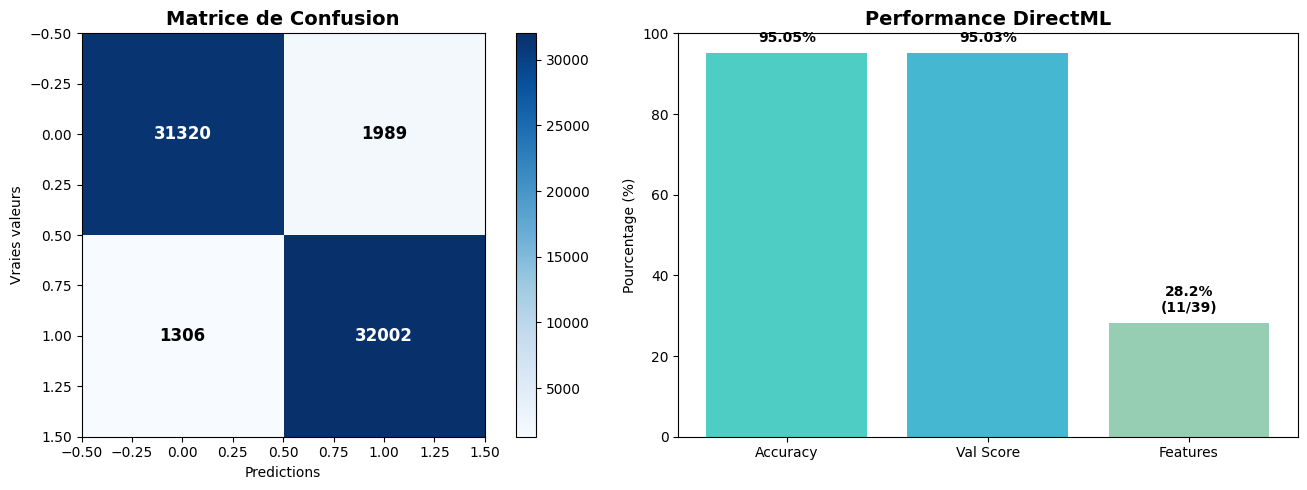


SYNTHESE

Configuration: k=7, metric=manhattan
Features: 11/39
Accuracy: 95.05%


In [3]:
"""
KNN optimisé pour GPU AMD Vega 7 sur WINDOWS avec DirectML (VERSION CORRIGÉE)

INSTALLATION:
pip install torch-directml numpy pandas scikit-learn matplotlib scipy
"""

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.spatial.distance import cdist
import time
import math
import gc

# Import DirectML pour GPU AMD sur Windows
print("="*80)
print("Initialisation GPU AMD avec DirectML")
print("="*80)

try:
    import torch_directml
    import torch
    
    dml = torch_directml.device()
    GPU_AVAILABLE = True
    DEVICE = dml
    
    print(f"DirectML initialise!")
    print(f"   Device: {dml}")
    print(f"   PyTorch version: {torch.__version__}")
    
except ImportError as e:
    print(f"DirectML non installe!")
    print(f"   Erreur: {e}")
    print(f"\nInstallation requise:")
    print(f"   pip install torch-directml")
    GPU_AVAILABLE = False
    DEVICE = "cpu"
    import torch

print("="*80 + "\n")

# ============== KNN AVEC GPU DirectML (VERSION OPTIMISÉE) ==============

def knn_directml_optimized(X_train, X_test, y_train, k=3, metric='manhattan', batch_size=100):
    """
    KNN optimisé pour GPU AMD avec DirectML - gestion mémoire améliorée
    """
    if not GPU_AVAILABLE:
        print("   GPU non disponible, utilisation CPU optimise")
        return knn_cpu_optimized(X_train, X_test, y_train, k, metric)
    
    try:
        # Conversion en tenseurs
        X_train_tensor = torch.FloatTensor(X_train).to(DEVICE)
        y_train_np = np.array(y_train)
        
        y_pred = []
        n_test = len(X_test)
        n_train = len(X_train)
        
        print(f"   Traitement {n_test} echantillons (batch={batch_size})...")
        
        # Traitement par batch
        for start_idx in range(0, n_test, batch_size):
            end_idx = min(start_idx + batch_size, n_test)
            
            if start_idx % (batch_size * 10) == 0:
                progress = (start_idx / n_test) * 100
                print(f"      Progression: {progress:.1f}%")
            
            # Batch de test
            X_test_batch = torch.FloatTensor(X_test[start_idx:end_idx]).to(DEVICE)
            
            # Calcul distances sur GPU
            try:
                if metric == 'manhattan':
                    # Optimisation: calcul par morceaux si trop grand
                    if n_train > 50000:
                        # Découper X_train en morceaux
                        chunk_size = 25000
                        all_distances = []
                        
                        for train_start in range(0, n_train, chunk_size):
                            train_end = min(train_start + chunk_size, n_train)
                            X_train_chunk = X_train_tensor[train_start:train_end]
                            
                            diff = X_test_batch.unsqueeze(1) - X_train_chunk.unsqueeze(0)
                            dist_chunk = torch.abs(diff).sum(dim=2)
                            all_distances.append(dist_chunk.cpu())
                            
                            del diff, dist_chunk
                            gc.collect()
                        
                        distances = torch.cat(all_distances, dim=1)
                    else:
                        diff = X_test_batch.unsqueeze(1) - X_train_tensor.unsqueeze(0)
                        distances = torch.abs(diff).sum(dim=2).cpu()
                        del diff
                        
                else:  # euclidean
                    if n_train > 50000:
                        chunk_size = 25000
                        all_distances = []
                        
                        for train_start in range(0, n_train, chunk_size):
                            train_end = min(train_start + chunk_size, n_train)
                            X_train_chunk = X_train_tensor[train_start:train_end]
                            
                            diff = X_test_batch.unsqueeze(1) - X_train_chunk.unsqueeze(0)
                            dist_chunk = torch.sqrt((diff ** 2).sum(dim=2) + 1e-8)
                            all_distances.append(dist_chunk.cpu())
                            
                            del diff, dist_chunk
                            gc.collect()
                        
                        distances = torch.cat(all_distances, dim=1)
                    else:
                        diff = X_test_batch.unsqueeze(1) - X_train_tensor.unsqueeze(0)
                        distances = torch.sqrt((diff ** 2).sum(dim=2) + 1e-8).cpu()
                        del diff
                
                # Trouver k plus proches voisins
                _, indices = torch.topk(distances, k, largest=False, dim=1)
                
                # Vote majoritaire
                for idx_row in indices:
                    labels = y_train_np[idx_row.numpy()]
                    most_common = np.bincount(labels).argmax()
                    y_pred.append(most_common)
                
                # Nettoyage
                del X_test_batch, distances, indices
                gc.collect()
                
            except Exception as e:
                print(f"   Erreur GPU, basculement CPU pour ce batch: {e}")
                # Fallback CPU pour ce batch
                X_test_cpu = X_test[start_idx:end_idx]
                y_pred_cpu = knn_cpu_optimized(X_train, X_test_cpu, y_train, k, metric)
                y_pred.extend(y_pred_cpu)
        
        del X_train_tensor
        gc.collect()
        
        return np.array(y_pred)
        
    except Exception as e:
        print(f"   Erreur DirectML: {e}")
        print(f"   Basculement complet sur CPU...")
        return knn_cpu_optimized(X_train, X_test, y_train, k, metric)

def knn_cpu_optimized(X_train, X_test, y_train, k=3, metric='manhattan'):
    """Version CPU optimisée avec scipy"""
    # Calcul vectorisé
    if metric == 'manhattan':
        distances = cdist(X_test, X_train, metric='cityblock')
    else:
        distances = cdist(X_test, X_train, metric='euclidean')
    
    # K plus proches
    k_indices = np.argpartition(distances, k, axis=1)[:, :k]
    k_labels = y_train[k_indices]
    
    # Vote majoritaire
    y_pred = np.array([np.bincount(labels).argmax() for labels in k_labels])
    
    return y_pred

# ============== RECUIT SIMULÉ FEATURES ==============

def simulated_annealing_features(X_train, y_train, X_val, y_val, 
                                 n_iterations=10, initial_temp=50):
    """Sélection features avec KNN GPU"""
    print("\n" + "="*60)
    print("RECUIT SIMULE - Selection Features KNN")
    print("="*60)
    
    n_features = X_train.shape[1]
    
    def evaluate_features(selected_indices):
        if len(selected_indices) == 0:
            return 0
        
        # Échantillonnage réduit
        sample_size = 2000
        
        train_idx = np.random.choice(len(X_train), min(sample_size, len(X_train)), replace=False)
        val_idx = np.random.choice(len(X_val), min(sample_size, len(X_val)), replace=False)
        
        X_train_sub = X_train[train_idx][:, selected_indices]
        y_train_sub = y_train[train_idx]
        X_val_sub = X_val[val_idx][:, selected_indices]
        y_val_sub = y_val[val_idx]
        
        # KNN avec GPU
        y_pred = knn_directml_optimized(X_train_sub, X_val_sub, y_train_sub, 
                                        k=5, metric='manhattan', batch_size=200)
        score = accuracy_score(y_val_sub, y_pred)
        
        # Pénalités
        n_selected = len(selected_indices)
        if n_selected < 8:
            score -= (8 - n_selected) * 0.03
        elif n_selected > 25:
            score -= (n_selected - 25) * 0.04
            
        return max(0, score)
    
    # Initialisation
    current_solution = np.random.choice(n_features, size=np.random.randint(10, 16), replace=False)
    current_score = evaluate_features(current_solution)
    best_solution = current_solution.copy()
    best_score = current_score
    
    print(f"Solution initiale: {len(current_solution)} features, score: {current_score:.3f}")
    
    temperature = initial_temp
    for iteration in range(n_iterations):
        neighbor_solution = current_solution.copy()
        operation = np.random.choice(['add', 'remove', 'replace'])
        
        if operation == 'add' and len(neighbor_solution) < n_features:
            available = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available) > 0:
                neighbor_solution = np.append(neighbor_solution, np.random.choice(available))
                
        elif operation == 'remove' and len(neighbor_solution) > 8:
            neighbor_solution = np.delete(neighbor_solution, np.random.randint(len(neighbor_solution)))
            
        elif operation == 'replace' and len(neighbor_solution) > 0:
            available = np.setdiff1d(np.arange(n_features), neighbor_solution)
            if len(available) > 0:
                idx = np.random.randint(len(neighbor_solution))
                neighbor_solution[idx] = np.random.choice(available)
        
        neighbor_score = evaluate_features(neighbor_solution)
        
        if neighbor_score > current_score:
            current_solution = neighbor_solution
            current_score = neighbor_score
        else:
            if np.random.random() < math.exp((neighbor_score - current_score) / temperature):
                current_solution = neighbor_solution
                current_score = neighbor_score
        
        if current_score > best_score:
            best_solution = current_solution.copy()
            best_score = current_score
            print(f"Iteration {iteration+1}: {len(best_solution)} features, score: {best_score:.3f}")
        
        temperature *= 0.95
    
    print(f"\nMeilleures features: {len(best_solution)}, score: {best_score:.3f}")
    return best_solution

# ============== RECUIT SIMULÉ HYPERPARAMÈTRES ==============

def simulated_annealing_params(X_train, y_train, X_val, y_val, 
                               n_iterations=6, initial_temp=10):
    """Optimisation hyperparamètres"""
    print("\n" + "="*60)
    print("RECUIT SIMULE - Hyperparametres KNN")
    print("="*60)
    
    sample_size = 800
    
    train_idx = np.random.choice(len(X_train), min(sample_size, len(X_train)), replace=False)
    val_idx = np.random.choice(len(X_val), min(sample_size, len(X_val)), replace=False)
    
    X_train_sub = X_train[train_idx]
    y_train_sub = y_train[train_idx]
    X_val_sub = X_val[val_idx]
    y_val_sub = y_val[val_idx]
    
    print(f"Echantillons: train={len(X_train_sub)}, val={len(X_val_sub)}")
    
    cache = {}
    
    def evaluate_params(params):
        key = (params['k'], params['metric'])
        if key in cache:
            return cache[key]
        
        try:
            y_pred = knn_directml_optimized(X_train_sub, X_val_sub, y_train_sub,
                                           k=params['k'], metric=params['metric'], batch_size=100)
            score = accuracy_score(y_val_sub, y_pred)
            cache[key] = score
            return score
        except:
            return 0
    
    # Init
    initial_k = 7
    current_params = {'k': initial_k, 'metric': 'manhattan'}
    current_score = evaluate_params(current_params)
    best_params = current_params.copy()
    best_score = current_score
    
    print(f"Init: k={initial_k}, score={current_score:.3f}")
    
    temperature = initial_temp
    for iteration in range(n_iterations):
        neighbor_params = current_params.copy()
        
        if np.random.random() < 0.6:
            neighbor_params['k'] = max(3, min(15, current_params['k'] + np.random.choice([-2, 2])))
        else:
            neighbor_params['metric'] = 'euclidean' if current_params['metric'] == 'manhattan' else 'manhattan'
        
        neighbor_score = evaluate_params(neighbor_params)
        
        if neighbor_score > current_score or np.random.random() < math.exp((neighbor_score - current_score) / temperature):
            current_params = neighbor_params
            current_score = neighbor_score
        
        if current_score > best_score:
            best_params = current_params.copy()
            best_score = current_score
        
        print(f"Iter {iteration+1}: k={neighbor_params['k']} {neighbor_params['metric']} score={neighbor_score:.3f}")
        temperature *= 0.75
    
    # Évaluation finale
    print("\nEvaluation finale...")
    y_pred_full = knn_directml_optimized(X_train, X_val, y_train,
                                         k=best_params['k'], metric=best_params['metric'], batch_size=200)
    final_score = accuracy_score(y_val, y_pred_full)
    
    print(f"\nMeilleurs parametres: k={best_params['k']}, metric={best_params['metric']}")
    print(f"Score final: {final_score:.3f}")
    
    return best_params, final_score

# ============== PROGRAMME PRINCIPAL ==============

if __name__ == "__main__":
    print("="*80)
    print("KNN OPTIMISE GPU AMD VEGA 7 (DirectML)")
    print("="*80)
    
    # Chargement
    df = pd.read_csv("balanced_dataset_hybrid_FULL.csv")
    columns_to_exclude = ['acq_date','X','Y','confidence']
    feature_columns = [col for col in df.columns if col not in columns_to_exclude and col != 'fire']
    
    X = df[feature_columns].values
    Y = df['fire'].values
    
    print(f"\nDataset: {X.shape[0]} echantillons, {X.shape[1]} features")
    
    # Normalisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, Y, test_size=0.20, random_state=42, stratify=Y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )
    
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    start_time = time.time()
    
    # ÉTAPE 1: Features
    print("\n" + "="*80)
    print("ETAPE 1: SELECTION FEATURES")
    print("="*80)
    
    selected_indices = simulated_annealing_features(
        X_train, y_train, X_val, y_val, n_iterations=8, initial_temp=40
    )
    
    X_train_opt = X_train[:, selected_indices]
    X_val_opt = X_val[:, selected_indices]
    X_test_opt = X_test[:, selected_indices]
    
    # ÉTAPE 2: Hyperparamètres
    print("\n" + "="*80)
    print("ETAPE 2: OPTIMISATION HYPERPARAMETRES")
    print("="*80)
    
    best_params, val_score = simulated_annealing_params(
        X_train_opt, y_train, X_val_opt, y_val, n_iterations=6, initial_temp=20
    )
    
    # ÉTAPE 3: Test final
    print("\n" + "="*80)
    print("ETAPE 3: EVALUATION FINALE")
    print("="*80)
    
    print("\nPrediction sur test set...")
    test_start = time.time()
    y_pred_test = knn_directml_optimized(X_train_opt, X_test_opt, y_train,
                                         k=best_params['k'], metric=best_params['metric'], batch_size=200)
    test_time = time.time() - test_start
    
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print(f"\nRESULTATS FINAUX:")
    print(f"   Accuracy: {test_accuracy*100:.2f}%")
    print(f"   Temps total: {time.time() - start_time:.2f}s")
    print(f"   Temps test: {test_time:.2f}s")
    
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred_test))
    
    print("\nMatrice de confusion:")
    cm = confusion_matrix(y_test, y_pred_test)
    print(cm)
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im = axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predictions')
    axes[0].set_ylabel('Vraies valeurs')
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=12, fontweight='bold')
    
    plt.colorbar(im, ax=axes[0])
    
    metrics = {
        'Accuracy': test_accuracy * 100,
        'Val Score': val_score * 100,
        'Features': len(selected_indices) / X.shape[1] * 100
    }
    
    bars = axes[1].bar(metrics.keys(), metrics.values(),
                       color=['#4ecdc4', '#45b7d1', '#96ceb4'])
    axes[1].set_title('Performance DirectML', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Pourcentage (%)')
    axes[1].set_ylim(0, 100)
    
    for bar, (key, value) in zip(bars, metrics.items()):
        if 'Features' in key:
            label = f'{value:.1f}%\n({len(selected_indices)}/{X.shape[1]})'
        else:
            label = f'{value:.2f}%'
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    label, ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('knn_directml_results.png', dpi=300, bbox_inches='tight')
    print("\nGraphiques sauvegardes: knn_directml_results.png")
    plt.show()
    
    print("\n" + "="*80)
    print("SYNTHESE")
    print("="*80)
    print(f"\nConfiguration: k={best_params['k']}, metric={best_params['metric']}")
    print(f"Features: {len(selected_indices)}/{X.shape[1]}")
    print(f"Accuracy: {test_accuracy*100:.2f}%")
    print("="*80)